In [10]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from football_analytics.analyses.passing.features import passing_feature_columns

import umap
import matplotlib.pyplot as plt

RANDOM_STATE = 42

# FEATURES = [...]  # your long feature list
ID_COLS = ["player_key", "player", "player_position"]

df = pd.read_parquet("../../../artifacts/features/player_level_wc2018.parquet")
passing_cols = passing_feature_columns()
passing_df = df[["player_key", "player_position", "player"] + passing_cols]

FEATURES = [
    'passes_per_90','short_passes_per_90','medium_passes_per_90','long_passes_per_90',
    'crosses_per90','switches_per90','throughballs_per90','cutbacks_per90','backheels_per90',
    'passes_under_pressure_per90','key_passes_per90','assists_per90','pct_passes_under_pressure',
    'avg_pass_length','std_pass_length','pct_short_pass','pct_med_pass','pct_long_pass',
    'pct_ground_pass','pct_low_pass','pct_high_pass','pct_left_foot_pass','pct_right_foot_pass',
    'pct_head_pass','pct_foot_pass','pct_other_pass','pct_keeper_arm_pass',
    'pct_progressive_passes','pct_lateral_passes','pct_defensive_passes',
    'pct_pass_from_def_third','pct_pass_from_mid_third','pct_pass_from_att_third',
    'pct_pass_from_left_channel','pct_pass_from_central_channel','pct_pass_from_right_channel',
    'pct_pass_to_def_third','pct_pass_to_mid_third','pct_pass_to_left_channel',
    'pct_pass_to_central_channel','pct_pass_to_right_channel',
    'pct_passes_final_third','pct_passes_into_box',
    'pct_pass_from_zone_dl','pct_pass_to_zone_dl','pct_pass_from_zone_dc','pct_pass_to_zone_dc',
    'pct_pass_from_zone_dr','pct_pass_to_zone_dr','pct_pass_from_zone_ml','pct_pass_to_zone_ml',
    'pct_pass_from_zone_mc','pct_pass_to_zone_mc','pct_pass_from_zone_mr','pct_pass_to_zone_mr',
    'pct_pass_from_zone_al','pct_pass_to_zone_al','pct_pass_from_zone_ac','pct_pass_to_zone_ac',
    'pct_pass_from_zone_ar','pct_pass_to_zone_ar',
    'pct_pass_def_to_mid','pct_pass_def_to_att','pct_pass_mid_to_att','pct_pass_mid_to_mid',
    'pct_pass_att_to_mid','pct_pass_def_to_def','pct_pass_att_to_att',
    'pct_pass_left_to_centre','pct_pass_left_to_right','pct_pass_right_to_centre',
    'pct_pass_right_to_left','pct_pass_centre_to_left','pct_pass_centre_to_right',
    'pct_pass_wide_to_box','pct_pass_centre_to_box','pct_pass_def_to_box',
    'ttl_passes_F','pct_passes_F','passes_F_per90',
    'ttl_passes_FR','pct_passes_FR','passes_FR_per90',
    'ttl_passes_R','pct_passes_R','passes_R_per90',
    'ttl_passes_BR','pct_passes_BR','passes_BR_per90',
    'ttl_passes_B','pct_passes_B','passes_B_per90',
    'ttl_passes_BL','pct_passes_BL','passes_BL_per90',
    'ttl_passes_L','pct_passes_L','passes_L_per90',
    'ttl_passes_FL','pct_passes_FL','passes_FL_per90',
    'pass_angle_mean_overall','pass_angle_var_overall',
    'pass_angle_mean_def_third','pass_angle_var_def_third',
    'pass_angle_mean_mid_third','pass_angle_var_mid_third',
    'pass_angle_mean_att_third','pass_angle_var_att_third',
    'pass_angle_mean_left_channel','pass_angle_var_left_channel',
    'pass_angle_mean_centre_channel','pass_angle_var_centre_channel',
    'pass_angle_mean_right_channel','pass_angle_var_right_channel'
]

In [11]:
df = passing_df.copy()
df = df[df["player_position"].notna()].copy()

DROP_GK = True
if DROP_GK:
    df = df[df["player_position"] != "Goalkeeper"].copy()

MIN_COUNT=5
counts = df["player_position"].value_counts()
keep_positions = counts[counts >= MIN_COUNT].index
df = df[df["player_position"].isin(keep_positions)].copy()
# Basic sanity: keep only players who actually have pass events/minutes
if "has_pass_events" in df.columns:
    df = df[df["has_pass_events"] == 1]
if "has_minutes" in df.columns:
    df = df[df["has_minutes"] == 1]

print(df.shape, df["player_position"].value_counts().head(10))


(459, 127) player_position
Left Center Back             47
Right Center Back            45
Right Back                   44
Right Center Midfield        38
Center Forward               37
Left Center Midfield         37
Left Back                    37
Left Wing                    31
Right Wing                   28
Center Attacking Midfield    19
Name: count, dtype: int64


In [34]:
df_train, df_test = train_test_split(
    df,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=df["player_position"]
)

print("train:", df_train.shape, "test:", df_test.shape)


train: (275, 127) test: (184, 127)


In [35]:
N_PCS = 20  # you used ~20 before; good starting point

preprocess_pca = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
    ("pca", PCA(n_components=N_PCS, random_state=RANDOM_STATE))
])

X_train_pca = preprocess_pca.fit_transform(df_train[FEATURES])
X_test_pca  = preprocess_pca.transform(df_test[FEATURES])

print(X_train_pca.shape, X_test_pca.shape)


(275, 20) (184, 20)


In [36]:
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.08,
    n_components=2,
    metric="euclidean",
    random_state=RANDOM_STATE
)

Z_train = umap_model.fit_transform(X_train_pca)
Z_test  = umap_model.transform(X_test_pca)

print(Z_train.shape, Z_test.shape)


C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(275, 2) (184, 2)


In [37]:
K = 10  # you were around 8–12; start at 10

kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto")
train_roles = kmeans.fit_predict(Z_train)
test_roles  = kmeans.predict(Z_test)

df_train = df_train.copy()
df_test = df_test.copy()

df_train["role_id"] = train_roles
df_test["role_id"] = test_roles

df_train["umap_1"], df_train["umap_2"] = Z_train[:,0], Z_train[:,1]
df_test["umap_1"],  df_test["umap_2"]  = Z_test[:,0],  Z_test[:,1]


C:\Users\enmat\anaconda3\envs\football-analytics-ml\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [38]:
sil_train = silhouette_score(Z_train, train_roles)
sil_test  = silhouette_score(Z_test,  test_roles)

print("Silhouette train:", round(sil_train, 3))
print("Silhouette test :", round(sil_test, 3))


Silhouette train: 0.465
Silhouette test : 0.471


In [39]:
train_sizes = df_train["role_id"].value_counts().sort_index()
test_sizes  = df_test["role_id"].value_counts().sort_index()

sizes = pd.DataFrame({"train": train_sizes, "test": test_sizes}).fillna(0).astype(int)
sizes["test_pct"] = sizes["test"] / sizes["test"].sum()
sizes["train_pct"] = sizes["train"] / sizes["train"].sum()
sizes["pct_diff"] = (sizes["test_pct"] - sizes["train_pct"]).abs()

sizes


,train,test,test_pct,train_pct,pct_diff
role_id,,,,,
0,13,5,0.027174,0.047273,0.020099
1,30,20,0.108696,0.109091,0.000395
2,43,25,0.135870,0.156364,0.020494
3,13,14,0.076087,0.047273,0.028814
4,35,30,0.163043,0.127273,0.035771
5,32,23,0.125000,0.116364,0.008636
6,36,26,0.141304,0.130909,0.010395
7,33,16,0.086957,0.120000,0.033043
8,24,19,0.103261,0.087273,0.015988


In [40]:
def role_position_table(df_):
    tab = pd.crosstab(df_["role_id"], df_["player_position"], normalize="index")
    return tab

tab_train = role_position_table(df_train)
tab_test  = role_position_table(df_test)

tab_train, tab_test


(player_position  Center Attacking Midfield  Center Back  \
 role_id                                                   
 0                                 0.307692     0.000000   
 1                                 0.000000     0.033333   
 2                                 0.000000     0.000000   
 3                                 0.000000     0.000000   
 4                                 0.000000     0.000000   
 5                                 0.000000     0.093750   
 6                                 0.055556     0.000000   
 7                                 0.000000     0.000000   
 8                                 0.166667     0.000000   
 9                                 0.062500     0.000000   
 
 player_position  Center Defensive Midfield  Center Forward  Left Back  \
 role_id                                                                 
 0                                      0.0        0.076923   0.000000   
 1                                      0.0        0.000

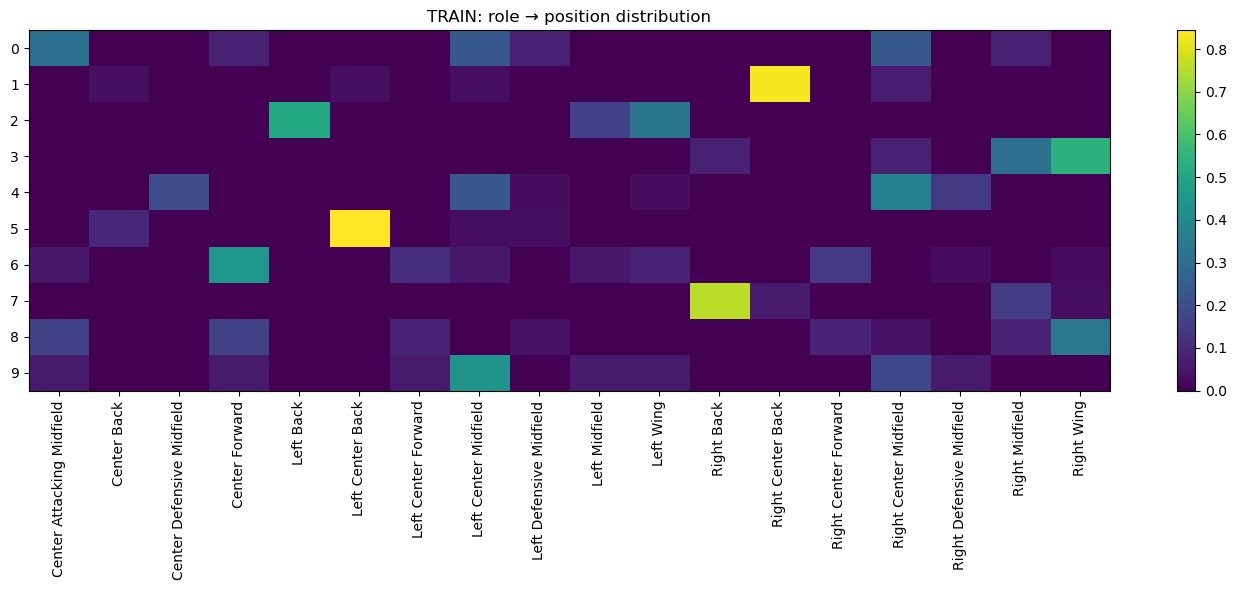

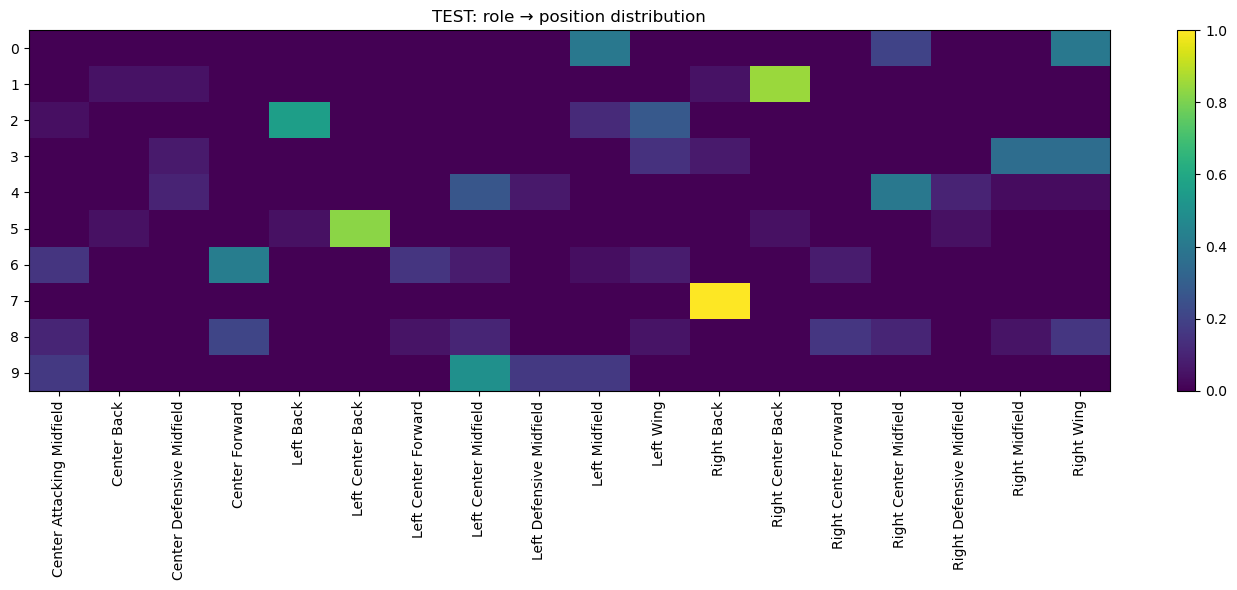

In [41]:
def plot_heatmap(tab, title):
    plt.figure(figsize=(14, 6))
    plt.imshow(tab.values, aspect="auto")
    plt.colorbar()
    plt.yticks(range(tab.shape[0]), tab.index)
    plt.xticks(range(tab.shape[1]), tab.columns, rotation=90)
    plt.title(title)
    plt.tight_layout()

plot_heatmap(tab_train, "TRAIN: role → position distribution")
plot_heatmap(tab_test,  "TEST: role → position distribution")
plt.show()


In [42]:
common_cols = sorted(set(tab_train.columns) | set(tab_test.columns))
A = tab_train.reindex(columns=common_cols, fill_value=0)
B = tab_test.reindex(columns=common_cols, fill_value=0)

role_shift = (A - B).abs().sum(axis=1)  # L1 distance per role (0 = identical)
role_shift.sort_values()


role_id
2    0.176744
5    0.260870
1    0.266667
6    0.324786
4    0.342857
7    0.484848
3    0.527473
8    0.679825
9    0.875000
0    1.600000
dtype: float64

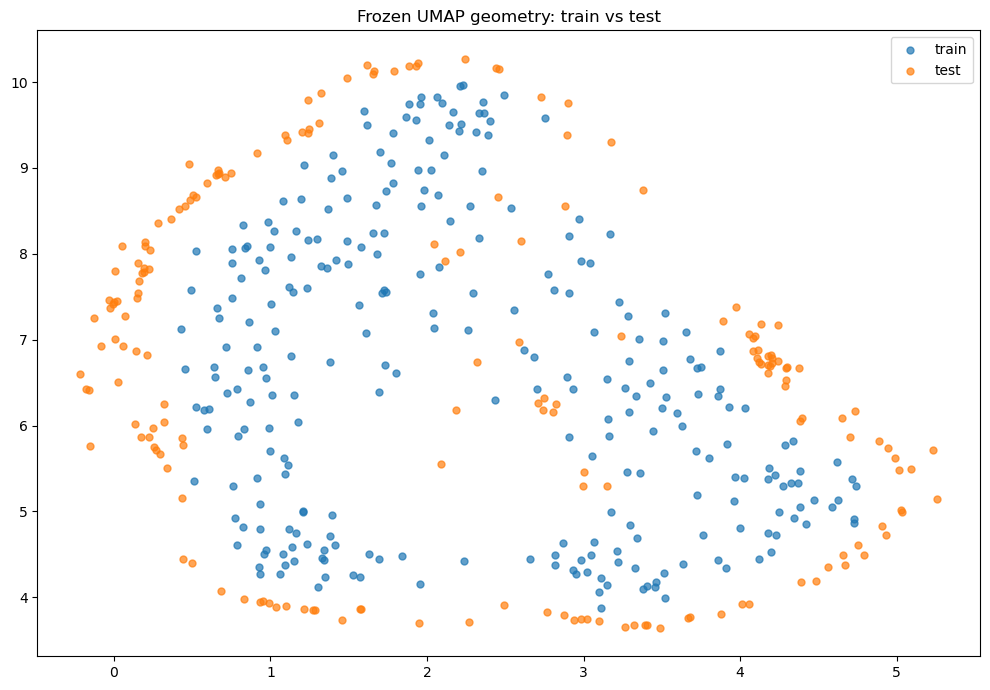

In [43]:
plt.figure(figsize=(10, 7))
plt.scatter(df_train["umap_1"], df_train["umap_2"], s=25, alpha=0.7, label="train")
plt.scatter(df_test["umap_1"], df_test["umap_2"], s=25, alpha=0.7, label="test")
plt.title("Frozen UMAP geometry: train vs test")
plt.legend()
plt.tight_layout()
plt.show()


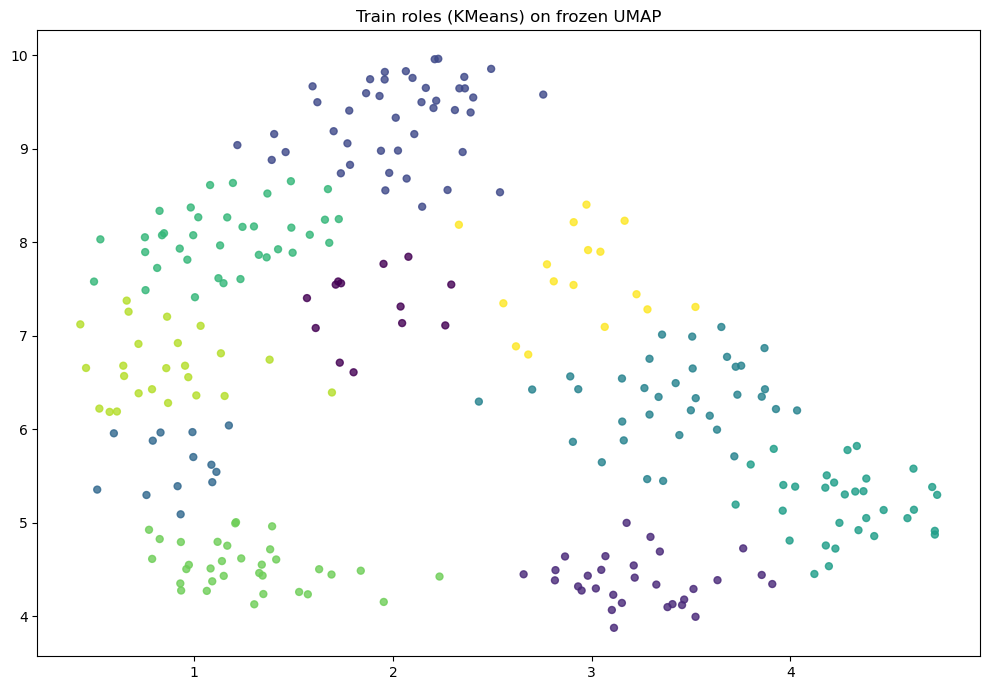

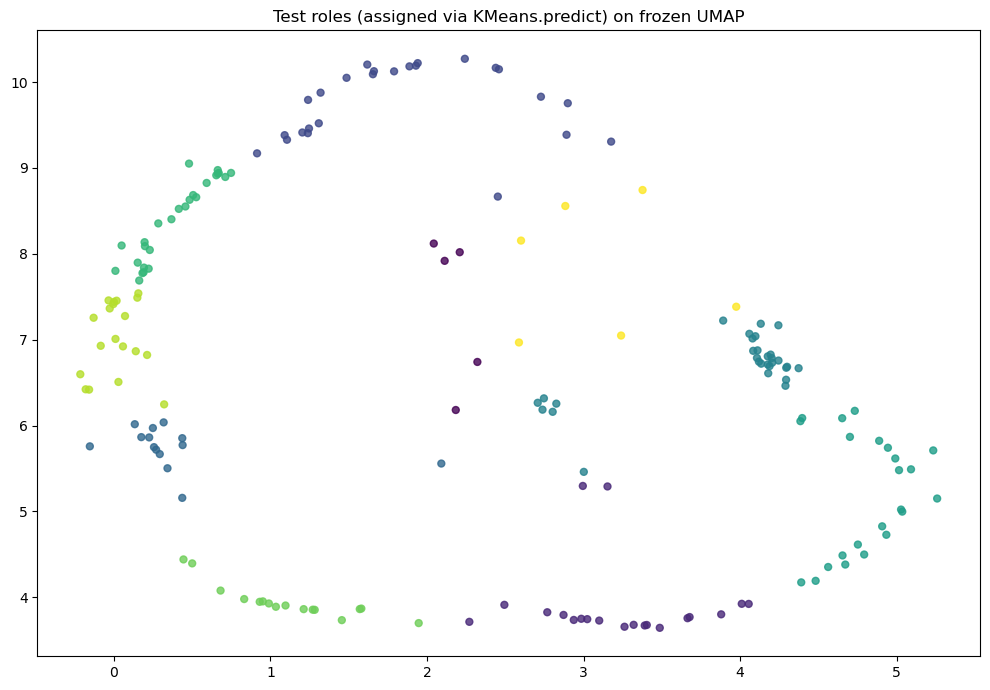

In [44]:
plt.figure(figsize=(10, 7))
plt.scatter(df_train["umap_1"], df_train["umap_2"], c=df_train["role_id"], s=25, alpha=0.8)
plt.title("Train roles (KMeans) on frozen UMAP")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 7))
plt.scatter(df_test["umap_1"], df_test["umap_2"], c=df_test["role_id"], s=25, alpha=0.8)
plt.title("Test roles (assigned via KMeans.predict) on frozen UMAP")
plt.tight_layout()
plt.show()
